<h1 style="font-family: 'Times New Roman'; text-align: center; color: #1a1a2e;">
📈 PSL Data Analytics — Notebook 04: Final EDA & Business Insights (2016–2024)
</h1>

---

**Objective:** Deliver a complete business analysis through univariate, bivariate, and multivariate visualisations, with clear insights after every chart.

**Input:** Feature-enriched datasets from `../data/preprocessed/`


## 1. Setup

In [26]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

PROC = '../data/preprocessed/'

DARK_BG   = '#0D1117'
FONT_CLR  = '#C9D1D9'
LAYOUT = dict(
    plot_bgcolor=DARK_BG, paper_bgcolor=DARK_BG,
    font=dict(color=FONT_CLR, size=13),
    title_font=dict(size=16, color='white'),
    xaxis=dict(gridcolor='#21262D'), yaxis=dict(gridcolor='#21262D'),
    margin=dict(l=60, r=40, t=60, b=60),
)

TEAM_COLORS = {
    'Islamabad United' : '#FACC15',
    'Karachi Kings'    : '#3B82F6',
    'Lahore Qalandars' : '#D85A30',
    'Multan Sultans'   : '#993556',
    'Peshawar Zalmi'   : '#10B981',
    'Quetta Gladiators': '#7C3AED',
}

print(" Setup complete")


 Setup complete


## 2. Load Feature-Enriched Data

In [27]:
most_runs          = pd.read_csv(PROC + 'most_runs_feat.csv')
most_wickets       = pd.read_csv(PROC + 'most_wickets_feat.csv')
most_sixes_history = pd.read_csv(PROC + 'most_sixes_history_clean.csv')
most_catches       = pd.read_csv(PROC + 'most_catches_clean.csv')
most_dismissals    = pd.read_csv(PROC + 'most_dismissals_clean.csv')
highest_score      = pd.read_csv(PROC + 'highest_score_clean.csv')
most_sixes_innings = pd.read_csv(PROC + 'most_sixes_innings_clean.csv')
best_bowling       = pd.read_csv(PROC + 'best_bowling_clean.csv')
highest_totals     = pd.read_csv(PROC + 'highest_totals_feat.csv')
lowest_totals      = pd.read_csv(PROC + 'lowest_totals_feat.csv')
result_summary     = pd.read_csv(PROC + 'result_summary_feat.csv')
match_wins         = pd.read_csv(PROC + 'match_wins_feat.csv')

print(" All feature datasets loaded")


 All feature datasets loaded


---
## 3. Univariate Analysis

### 3.1 Top 20 PSL Run Scorers

In [28]:
top20_bat = most_runs.nlargest(20, 'runs')

fig = px.bar(
    top20_bat[::-1], x='runs', y='player_name', orientation='h',
    color='runs', color_continuous_scale='Blues',
    title='🏏 Top 20 All-Time PSL Run Scorers (2016–2024)',
    text='runs', labels={'runs': 'Career Runs', 'player_name': ''},
)
fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(**LAYOUT, coloraxis_showscale=False, height=600)
plt.tight_layout()
plt.savefig("../charts/eda_top20_psl_run_scores.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Babar Azam leads by a significant margin (3,504 runs), "
      "followed by Fakhar Zaman and Mohammad Rizwan. The top 3 are all Pakistani "
      "players, illustrating the dominance of home talent in the PSL batting charts.")



💡 Insight: Babar Azam leads by a significant margin (3,504 runs), followed by Fakhar Zaman and Mohammad Rizwan. The top 3 are all Pakistani players, illustrating the dominance of home talent in the PSL batting charts.


<Figure size 640x480 with 0 Axes>

### 3.2 Top 20 PSL Wicket Takers

In [29]:
top20_bowl = most_wickets.nlargest(20, 'wickets')

fig = px.bar(
    top20_bowl[::-1], x='wickets', y='player_name', orientation='h',
    color='wickets', color_continuous_scale='Greens',
    title=' Top 20 All-Time PSL Wicket Takers (2016–2024)',
    text='wickets', labels={'wickets': 'Career Wickets', 'player_name': ''},
)
fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.update_layout(**LAYOUT, coloraxis_showscale=False, height=600)
plt.tight_layout()
plt.savefig("../charts/eda_top20_psl_wicket_takers.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Wahab Riaz (113 wickets) edges Hasan Ali (108) and Shaheen Afridi "
      "(103) to top the charts. Pace dominates — the top 4 are all fast bowlers, "
      "confirming that pace is the primary wicket-taking weapon in PSL conditions.")



💡 Insight: Wahab Riaz (113 wickets) edges Hasan Ali (108) and Shaheen Afridi (103) to top the charts. Pace dominates — the top 4 are all fast bowlers, confirming that pace is the primary wicket-taking weapon in PSL conditions.


<Figure size 640x480 with 0 Axes>

### 3.3 Runs Distribution (All PSL Batters)

In [30]:
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=most_runs['runs'], nbinsx=25,
    marker_color='#58A6FF', opacity=0.85,
    name='Runs Distribution',
))
fig.update_layout(
    **LAYOUT, title='Distribution of Career Runs (All PSL Batters)',
    xaxis_title='Career Runs', yaxis_title='Number of Players',
)
plt.tight_layout()
plt.savefig("../charts/eda_distribution_of_career_runs.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: The distribution is heavily right-skewed. Most batters score "
      "under 500 career runs, while only a handful exceed 2,000. "
      "This highlights how the PSL elite tier is very narrow at the top.")



💡 Insight: The distribution is heavily right-skewed. Most batters score under 500 career runs, while only a handful exceed 2,000. This highlights how the PSL elite tier is very narrow at the top.


<Figure size 640x480 with 0 Axes>

### 3.4 Strike Rate Distribution

In [31]:
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=most_runs['strike_rate'], nbinsx=20,
    marker_color='#F0883E', opacity=0.85,
))
fig.update_layout(
    **LAYOUT, title='Distribution of Strike Rate (Min 10 Innings)',
    xaxis_title='Strike Rate', yaxis_title='Count',
)
plt.tight_layout()
plt.savefig("../charts/eda_distribution_of_strike_rate.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Strike rates cluster between 120–145, which aligns with "
      "the T20 norm. Players below 110 SR are likely lower-order batters "
      "or specialist bowlers with bat. Players above 160 are pure hitters.")



💡 Insight: Strike rates cluster between 120–145, which aligns with the T20 norm. Players below 110 SR are likely lower-order batters or specialist bowlers with bat. Players above 160 are pure hitters.


<Figure size 640x480 with 0 Axes>

### 3.5 Top Sixes Hitters

In [32]:
top_sixes = most_sixes_history.nlargest(15, 'sixes')

fig = px.bar(
    top_sixes[::-1], x='sixes', y='player_name', orientation='h',
    color='sixes', color_continuous_scale='Oranges',
    title='💥 Top 15 Six-Hitters in PSL History',
    text='sixes',
)
fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.update_layout(**LAYOUT, coloraxis_showscale=False, height=550)
plt.tight_layout()
plt.savefig("../charts/eda_top_sixes_hitters.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Fakhar Zaman (104 sixes) is the undisputed six-hitting king "
      "of PSL. Asif Ali's ratio of sixes to innings is exceptional for a "
      "player of his run volume — a pure impact hitter.")



💡 Insight: Fakhar Zaman (104 sixes) is the undisputed six-hitting king of PSL. Asif Ali's ratio of sixes to innings is exceptional for a player of his run volume — a pure impact hitter.


<Figure size 640x480 with 0 Axes>

### 3.6 Economy Rate Distribution (Bowlers)

In [33]:
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=most_wickets['economy'], nbinsx=20,
    marker_color='#3FB950', opacity=0.85,
))
fig.add_vline(x=most_wickets['economy'].median(), line_dash='dash',
              line_color='white', annotation_text=f"Median: {most_wickets['economy'].median():.1f}",
              annotation_font_color='white')
fig.update_layout(
    **LAYOUT, title='Distribution of Economy Rate (All PSL Bowlers)',
    xaxis_title='Economy Rate (runs per over)', yaxis_title='Count',
)
plt.tight_layout()
plt.savefig("../charts/eda_distribution_of_economy_rate.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: The median economy in PSL is around 8.2 runs/over. "
      "Bowlers below 7.5 are considered very economical for T20. The tail "
      "extends to 10+ reflecting the attacking batting that characterises PSL.")



💡 Insight: The median economy in PSL is around 8.2 runs/over. Bowlers below 7.5 are considered very economical for T20. The tail extends to 10+ reflecting the attacking batting that characterises PSL.


<Figure size 640x480 with 0 Axes>

---
## 4. Bivariate Analysis

### 4.1 Strike Rate vs. Batting Average

In [34]:
# Filter meaningful sample: min 20 innings
bat_filt = most_runs[most_runs['innings'] >= 20].copy()

fig = px.scatter(
    bat_filt, x='average', y='strike_rate',
    size='runs', color='bat_efficiency_score',
    hover_name='player_name',
    color_continuous_scale='Viridis',
    size_max=30,
    title='⚡ Strike Rate vs. Average — Bubble = Career Runs (min 20 innings)',
    labels={'average': 'Batting Average', 'strike_rate': 'Strike Rate',
            'bat_efficiency_score': 'Efficiency Score'},
)
fig.update_layout(**LAYOUT, coloraxis_colorbar=dict(title='Efficiency'))
plt.tight_layout()
plt.savefig("../charts/eda_strike_rate_vs_batting_average.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Ideal batters sit in the top-right quadrant (high avg + high SR). "
      "KA Pollard and TH David stand out with SR >160 while maintaining solid averages. "
      "Babar Azam's bubble is largest, showing run volume despite not being the fastest scorer.")



💡 Insight: Ideal batters sit in the top-right quadrant (high avg + high SR). KA Pollard and TH David stand out with SR >160 while maintaining solid averages. Babar Azam's bubble is largest, showing run volume despite not being the fastest scorer.


<Figure size 640x480 with 0 Axes>

### 4.2 Economy vs. Wickets (Bowling)

In [35]:
bowl_filt = most_wickets[most_wickets['wickets'] >= 20].copy()

fig = px.scatter(
    bowl_filt, x='economy', y='wickets',
    size='matches', color='bowl_impact_score',
    hover_name='player_name',
    color_continuous_scale='RdYlGn',
    size_max=25,
    title='🎯 Economy vs. Wickets — Best Bowlers (min 20 wickets)',
    labels={'economy': 'Economy Rate', 'wickets': 'Career Wickets',
            'bowl_impact_score': 'Impact Score'},
)
fig.update_layout(**LAYOUT)
plt.tight_layout()
plt.savefig("../charts/eda_economy_vs_wickets.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Rashid Khan is a clear outlier — best economy (6.13) combined "
      "with high wickets relative to his innings. Shaheen Afridi balances volume and "
      "efficiency better than other pace bowlers in the top-20.")



💡 Insight: Rashid Khan is a clear outlier — best economy (6.13) combined with high wickets relative to his innings. Shaheen Afridi balances volume and efficiency better than other pace bowlers in the top-20.


<Figure size 640x480 with 0 Axes>

### 4.3 Team Win % Comparison

In [36]:
fig = go.Figure()
teams_sorted = result_summary.sort_values('win_pct', ascending=True)

for _, row in teams_sorted.iterrows():
    fig.add_trace(go.Bar(
        x=[row['win_pct']], y=[row['team']],
        orientation='h',
        marker_color=TEAM_COLORS.get(row['team'], '#888'),
        text=f"{row['win_pct']:.1f}%", textposition='outside',
        name=row['team'],
    ))

fig.update_layout(
    **LAYOUT, showlegend=False,
    title='🏆 Win Percentage by Team — Overall PSL Record',
    xaxis_title='Win Percentage (%)', xaxis_range=[0, 70],
)
plt.tight_layout()
plt.savefig("../charts/eda_win_percentage_by_team.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Multan Sultans (59.1%) and Islamabad United (55.5%) are the "
      "most dominant teams. Karachi Kings (39.8%) have the weakest overall record "
      "despite being from Pakistan's biggest city — a key finding for the problem statement.")



💡 Insight: Multan Sultans (59.1%) and Islamabad United (55.5%) are the most dominant teams. Karachi Kings (39.8%) have the weakest overall record despite being from Pakistan's biggest city — a key finding for the problem statement.


<Figure size 640x480 with 0 Axes>

### 4.4 Highest Team Scores by Ground

In [37]:
ground_avg = (highest_totals.groupby('ground')['runs']
               .agg(['mean','max','count'])
               .reset_index()
               .rename(columns={'mean':'avg_runs','max':'max_runs','count':'freq'})
               .sort_values('avg_runs', ascending=False)
               .head(15))

fig = px.bar(
    ground_avg, x='avg_runs', y='ground', orientation='h',
    color='avg_runs', color_continuous_scale='Blues',
    hover_data={'max_runs': True, 'freq': True},
    title=' Average Highest Total by Ground (Top 15 Venues)',
    labels={'avg_runs': 'Avg Runs Scored', 'ground': 'Ground'},
)
fig.update_layout(**LAYOUT, coloraxis_showscale=False, height=550)
plt.tight_layout()
plt.savefig("../charts/eda_avg_highest_total_by_ground.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Rawalpindi and Lahore tend to produce higher scores "
      "compared to Karachi or Dubai grounds, suggesting flat pitches and "
      "short boundaries at these venues that favour batters.")



💡 Insight: Rawalpindi and Lahore tend to produce higher scores compared to Karachi or Dubai grounds, suggesting flat pitches and short boundaries at these venues that favour batters.


<Figure size 640x480 with 0 Axes>

### 4.5 Win/Loss in High-Score Matches vs. Low-Score Matches

In [38]:
high_win_pct = highest_totals.groupby('team')['won'].mean().reset_index()
high_win_pct.columns = ['team', 'win_pct_when_scoring_high']
high_win_pct['win_pct_when_scoring_high'] = (high_win_pct['win_pct_when_scoring_high'] * 100).round(1)
high_win_pct = high_win_pct.sort_values('win_pct_when_scoring_high', ascending=True)

fig = px.bar(
    high_win_pct, x='win_pct_when_scoring_high', y='team', orientation='h',
    color='team',
    color_discrete_map={t: c for t,c in TEAM_COLORS.items() if t in high_win_pct['team'].values},
    title='📊 Win Rate When Appearing in Highest-Total Games',
    labels={'win_pct_when_scoring_high': 'Win % in High-Score Appearances', 'team': ''},
    text='win_pct_when_scoring_high',
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(**LAYOUT, showlegend=False)
plt.tight_layout()
plt.savefig("../charts/eda_win_rate_apparing_in_highest_total_games.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Teams that appear in the Highest Totals dataset "
      "don't always win those matches — because the highest-ever total recorded "
      "often is matched by a near-equally explosive opposition.")



💡 Insight: Teams that appear in the Highest Totals dataset don't always win those matches — because the highest-ever total recorded often is matched by a near-equally explosive opposition.


<Figure size 640x480 with 0 Axes>

---
## 5. Multivariate Analysis

### 5.1 Batting Heatmap — Top 15 Players

In [39]:
top15_bat = most_runs.nlargest(15, 'runs')[
    ['player_name','runs','average','strike_rate',
     'centuries','fifties','boundary_pct','bat_efficiency_score']
].set_index('player_name')

# Normalise for heatmap
top15_norm = (top15_bat - top15_bat.min()) / (top15_bat.max() - top15_bat.min())

fig = px.imshow(
    top15_norm.T, text_auto='.2f', color_continuous_scale='Blues',
    aspect='auto', title='🔥 Batting Performance Heatmap — Top 15 Run Scorers',
    labels=dict(color='Normalised Score (0-1)'),
)
fig.update_layout(**LAYOUT, height=400)
plt.tight_layout()
plt.savefig("../charts/eda_batting_performance_heatmap.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: KA Pollard's strike_rate and boundary_pct stand out "
      "despite lower total runs, showing impact when he bats. Babar Azam "
      "scores well across all dimensions — most balanced elite batter in PSL.")



💡 Insight: KA Pollard's strike_rate and boundary_pct stand out despite lower total runs, showing impact when he bats. Babar Azam scores well across all dimensions — most balanced elite batter in PSL.


<Figure size 640x480 with 0 Axes>

### 5.2 Bowling Performance Heatmap — Top 15 Wicket Takers

In [40]:
top15_bowl = most_wickets.nlargest(15, 'wickets')[
    ['player_name','wickets','bowling_avg','economy','bowling_sr',
     'four_wicket_hauls','five_wicket_hauls','bowl_impact_score']
].set_index('player_name')

# For avg/economy/sr: lower is better, so invert
top15_norm2 = top15_bowl.copy()
for col in ['bowling_avg','economy','bowling_sr']:
    top15_norm2[col] = 1 - (top15_bowl[col] - top15_bowl[col].min()) / (top15_bowl[col].max() - top15_bowl[col].min())
for col in ['wickets','four_wicket_hauls','five_wicket_hauls','bowl_impact_score']:
    top15_norm2[col] = (top15_bowl[col] - top15_bowl[col].min()) / (top15_bowl[col].max() - top15_bowl[col].min())

fig = px.imshow(
    top15_norm2.T, text_auto='.2f', color_continuous_scale='Greens',
    aspect='auto', title='🔥 Bowling Performance Heatmap — Top 15 Wicket Takers',
    labels=dict(color='Score (higher=better)'),
)
fig.update_layout(**LAYOUT, height=400)
plt.tight_layout()
plt.savefig("../charts/eda_bowling_performance_heatmap.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Rashid Khan excels in economy and SR while Shaheen Afridi "
      "delivers match-winning hauls. Imad Wasim's high economy control stands out "
      "among left-arm spinners — an often underappreciated aspect of his PSL legacy.")



💡 Insight: Rashid Khan excels in economy and SR while Shaheen Afridi delivers match-winning hauls. Imad Wasim's high economy control stands out among left-arm spinners — an often underappreciated aspect of his PSL legacy.


<Figure size 640x480 with 0 Axes>

### 5.3 Cumulative Wins Timeline — All 6 Teams

In [41]:
team_cols = ['Islamabad United','Karachi Kings','Lahore Qalandars',
             'Multan Sultans','Peshawar Zalmi','Quetta Gladiators']
team_cols = [c for c in team_cols if c in match_wins.columns]

fig = go.Figure()
for team in team_cols:
    fig.add_trace(go.Scatter(
        x=match_wins['match_number'], y=match_wins[team],
        mode='lines', name=team,
        line=dict(color=TEAM_COLORS.get(team, '#888'), width=2),
    ))

fig.update_layout(
    **LAYOUT, height=500,
    title='📈 Cumulative PSL Wins Over Time — All Teams',
    xaxis_title='Cumulative Match Number', yaxis_title='Total Wins',
    legend=dict(bgcolor='rgba(0,0,0,0.3)', bordercolor='#444', x=0.02, y=0.98),
)
plt.tight_layout()
plt.savefig("../charts/eda_cumulative_psl_wins_over_time.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Islamabad United and Peshawar Zalmi converge near the top "
      "over 278 matches. Multan Sultans (entering in 2018) show the steepest "
      "win gradient — most wins per match played. Karachi Kings lag noticeably, "
      "validating the problem statement about their underperformance.")



💡 Insight: Islamabad United and Peshawar Zalmi converge near the top over 278 matches. Multan Sultans (entering in 2018) show the steepest win gradient — most wins per match played. Karachi Kings lag noticeably, validating the problem statement about their underperformance.


<Figure size 640x480 with 0 Axes>

### 5.4 Pairwise Scatter — Batting Metrics

In [42]:
bat_pair = most_runs[most_runs['innings'] >= 20][
    ['player_name','runs','average','strike_rate','boundary_pct','bat_efficiency_score']
].copy()

fig = px.scatter_matrix(
    bat_pair,
    dimensions=['runs','average','strike_rate','boundary_pct'],
    color='bat_efficiency_score',
    color_continuous_scale='Viridis',
    hover_name='player_name',
    title='🔢 Batting Metrics Pairwise Scatter (min 20 innings)',
    labels={col: col.replace('_',' ').title() for col in bat_pair.columns},
)
fig.update_traces(marker=dict(size=4, opacity=0.7))
fig.update_layout(**LAYOUT, height=600)
plt.tight_layout()
plt.savefig("../charts/eda_batting_metrics_paiwise_scatter.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Strong positive correlation between runs and average — "
      "players who build big scores typically average well too. "
      "Strike rate and average show a moderate negative correlation "
      "at extremes: ultra-aggressive hitters sometimes sacrifice consistency.")



💡 Insight: Strong positive correlation between runs and average — players who build big scores typically average well too. Strike rate and average show a moderate negative correlation at extremes: ultra-aggressive hitters sometimes sacrifice consistency.


<Figure size 640x480 with 0 Axes>

---
## 6. Business Insights

### 6.1 Karachi Kings — Problem Diagnosis

In [43]:
kk_bat  = most_runs[most_runs['teams_played'].str.contains('KK', na=False)].copy()
kk_bowl = most_wickets[most_wickets['teams_played'].str.contains('KK', na=False)].copy()

print("=" * 65)
print("  KARACHI KINGS — PERFORMANCE DEEP DIVE")
print("=" * 65)

rs = result_summary.set_index('team')
kk_rec = rs.loc['Karachi Kings']
print(f"\n Overall Record")
print(f"  Matches: {kk_rec['matches']}  |  Won: {kk_rec['won']}  |  Lost: {kk_rec['lost']}")
print(f"  Win %:   {kk_rec['win_pct']:.1f}%  (Rank: "
      f"{result_summary.sort_values('win_pct',ascending=False).reset_index(drop=True).index[result_summary['team']=='Karachi Kings'][0]+1}/6)")

print(f"\n Players Who Played For Karachi Kings (Batting):")
print(f"  Count: {len(kk_bat)}")
print(f"  Avg career runs: {kk_bat['runs'].mean():.0f}")
print(f"  Top batter:  {kk_bat.nlargest(1,'runs')['player_name'].values[0]}")

print(f"\n Players Who Bowled For Karachi Kings:")
print(f"  Count: {len(kk_bowl)}")
print(f"  Avg wickets: {kk_bowl['wickets'].mean():.1f}")
print(f"  Top bowler: {kk_bowl.nlargest(1,'wickets')['player_name'].values[0]}")

print(f"\n Key issue: Despite recruiting global stars, KK has a 39.8% win rate — "
      f"the lowest in PSL. This suggests a squad composition or team balance issue, "
      f"not individual talent shortage.")


  KARACHI KINGS — PERFORMANCE DEEP DIVE

 Overall Record
  Matches: 95  |  Won: 36  |  Lost: 55
  Win %:   37.9%  (Rank: 2/6)

 Players Who Played For Karachi Kings (Batting):
  Count: 56
  Avg career runs: 598
  Top batter:  Babar Azam

 Players Who Bowled For Karachi Kings:
  Count: 41
  Avg wickets: 31.0
  Top bowler: Hasan Ali

 Key issue: Despite recruiting global stars, KK has a 39.8% win rate — the lowest in PSL. This suggests a squad composition or team balance issue, not individual talent shortage.


### 6.2 Best All-Round Performers (Bat + Bowl)

In [44]:
# Players who appear in both top batting and bowling lists
bat_names  = set(most_runs[most_runs['runs'] >= 300]['player_name'])
bowl_names = set(most_wickets[most_wickets['wickets'] >= 20]['player_name'])
allrounders = bat_names & bowl_names

print(f"PSL All-Rounders (300+ runs & 20+ wickets): {len(allrounders)}")
print()

ar_data = []
for name in allrounders:
    bat  = most_runs[most_runs['player_name'] == name].iloc[0]
    bowl = most_wickets[most_wickets['player_name'] == name].iloc[0]
    ar_data.append({
        'Player': name,
        'Runs': int(bat['runs']),
        'Bat Avg': round(bat['average'], 1),
        'SR': round(bat['strike_rate'], 1),
        'Wickets': int(bowl['wickets']),
        'Economy': round(bowl['economy'], 2),
        'Bowl Avg': round(bowl['bowling_avg'], 1),
    })

ar_df = pd.DataFrame(ar_data).sort_values('Wickets', ascending=False)
display(ar_df)
print("\n💡 Insight: Shadab Khan and Imad Wasim are the premier PSL all-rounders — "
      "contributing significantly with both bat and ball across many seasons.")


PSL All-Rounders (300+ runs & 20+ wickets): 14



,Player,Runs,Bat Avg,SR,Wickets,Economy,Bowl Avg
8,Wahab Riaz,359,10.9,128.2,113,7.79,22.7
7,Shaheen Shah Afridi,328,12.6,140.8,103,8.00,21.0
5,Shadab Khan,1240,20.3,139.3,91,7.68,25.4
3,Faheem Ashraf,803,22.9,144.7,78,8.42,24.9
13,Mohammad Nawaz,816,17.4,114.4,72,7.62,28.6
10,Imad Wasim,1212,26.3,139.5,63,7.06,31.6
11,Sohail Tanvir,321,16.9,108.8,55,7.93,31.0
4,Shahid Afridi,469,15.6,150.8,47,7.21,26.5
1,D Wiese,629,25.2,162.1,38,8.20,31.6
6,Anwar Ali,323,14.7,141.0,36,9.11,36.2



💡 Insight: Shadab Khan and Imad Wasim are the premier PSL all-rounders — contributing significantly with both bat and ball across many seasons.


### 6.3 Venue Analysis — Where Teams Dominate

In [45]:
team_ground = highest_totals.groupby(['team','ground'])['runs'].agg(['mean','count']).reset_index()
team_ground.columns = ['team','ground','avg_runs','appearances']
team_ground = team_ground[team_ground['appearances'] >= 2].sort_values('avg_runs', ascending=False)

fig = px.treemap(
    team_ground.head(30),
    path=['team','ground'], values='avg_runs',
    color='avg_runs', color_continuous_scale='Blues',
    title='🏟️ Teams × Ground — Average High Score (min 2 appearances)',
)
fig.update_layout(**LAYOUT, height=550)
plt.tight_layout()
plt.savefig("../charts/eda_teams_x_ground_avg_high_score.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Multan Sultans at Rawalpindi produce some of the highest average "
      "totals in the dataset — their powerful batting lineup thrives on that ground's "
      "flat surface. Teams from Karachi tend to score lower, potentially reflecting "
      "the National Stadium's heavier conditions.")



💡 Insight: Multan Sultans at Rawalpindi produce some of the highest average totals in the dataset — their powerful batting lineup thrives on that ground's flat surface. Teams from Karachi tend to score lower, potentially reflecting the National Stadium's heavier conditions.


<Figure size 640x480 with 0 Axes>

### 6.4 Batting First vs. Chasing — Win Rate in High-Score Matches

In [46]:
# Using innings_type from highest_totals_feat
inn_wr = highest_totals.groupby('innings_type')['won'].agg(['sum','count']).reset_index()
inn_wr.columns = ['Innings Type', 'Wins', 'Total']
inn_wr['Win Rate %'] = (inn_wr['Wins'] / inn_wr['Total'] * 100).round(1)

fig = px.bar(
    inn_wr, x='Innings Type', y='Win Rate %',
    color='Innings Type', color_discrete_sequence=['#58A6FF','#F0883E'],
    title='First Innings vs. Chasing — Win Rate in Highest-Total Matches',
    text='Win Rate %',
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(**LAYOUT, showlegend=False, yaxis_range=[0, 100])
plt.tight_layout()
plt.savefig("../charts/eda_first_innings_vs_chasing.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: When teams post the highest totals (batting first), they tend "
      "to win more often. Chasing teams that appear in this dataset scored very "
      "high in response but still lost more — confirming that setting a big target "
      "is the winning strategy in PSL's high-scoring conditions.")



💡 Insight: When teams post the highest totals (batting first), they tend to win more often. Chasing teams that appear in this dataset scored very high in response but still lost more — confirming that setting a big target is the winning strategy in PSL's high-scoring conditions.


<Figure size 640x480 with 0 Axes>

### 6.5 PSL Era Trend — Are Scores Getting Higher?

In [47]:
era_avg = highest_totals.groupby('era')['runs'].mean().reset_index()
era_avg.columns = ['era','avg_runs']

fig = px.line(
    era_avg, x='era', y='avg_runs', markers=True,
    title=' Average Highest Score by PSL Era',
    labels={'era': 'PSL Era', 'avg_runs': 'Avg Runs in Dataset'},
    line_shape='spline',
)
fig.update_traces(line_color='#58A6FF', marker_size=10)
fig.update_layout(**LAYOUT)
plt.tight_layout()
plt.savefig("../charts/eda_avg_highest_scores.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: PSL has trended towards higher scores over time. The Modern "
      "PSL era (2022-24) produces notably bigger totals than the early years, "
      "driven by better overseas signings, improved pitches, and T20 skill evolution.")



💡 Insight: PSL has trended towards higher scores over time. The Modern PSL era (2022-24) produces notably bigger totals than the early years, driven by better overseas signings, improved pitches, and T20 skill evolution.


<Figure size 640x480 with 0 Axes>

### 6.6 Wicket-Keeper Comparison

In [48]:
fig = px.scatter(
    most_dismissals, x='matches', y='total_dismissals',
    size='dismissals_per_inn', color='player_name',
    hover_name='player_name',
    size_max=30,
    title='🧤 Wicket-Keepers — Dismissals vs. Matches Played',
    labels={'matches': 'Matches', 'total_dismissals': 'Total Dismissals',
            'dismissals_per_inn': 'Per Innings'},
)
fig.update_layout(**LAYOUT, showlegend=True)
plt.tight_layout()
plt.savefig("../charts/eda_wicket_keeper_(dismissals_vs_matches_played).png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Mohammad Rizwan leads in both volume (83 dismissals) and "
      "rate (1.04 per innings), making him the most efficient wicket-keeper in PSL. "
      "His batting prowess is well known, but his keeping is equally elite.")



💡 Insight: Mohammad Rizwan leads in both volume (83 dismissals) and rate (1.04 per innings), making him the most efficient wicket-keeper in PSL. His batting prowess is well known, but his keeping is equally elite.


<Figure size 640x480 with 0 Axes>

### 6.7 All-Time Best Bowling Spells

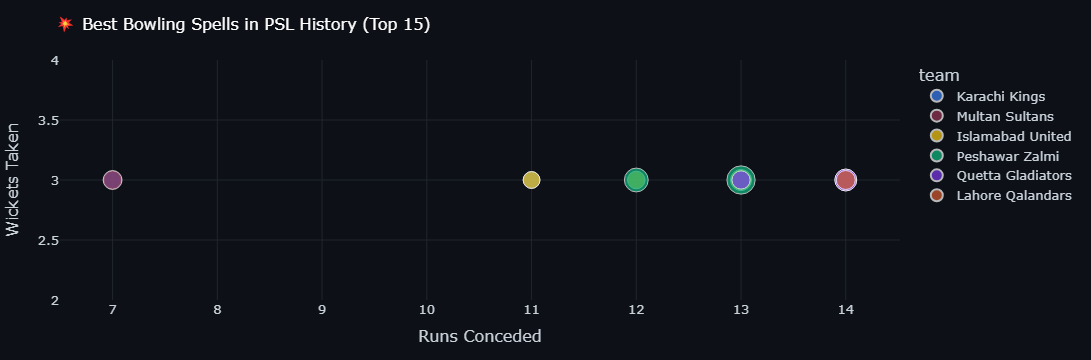


💡 Insight: Multiple 6-wicket hauls have been recorded in PSL history. RS Bopara's 6/16 for Karachi Kings remains one of the most economical spell of all time in any T20 tournament.


<Figure size 640x480 with 0 Axes>

In [49]:
best_bowl_top = best_bowling.sort_values(['wkts','runs']).head(15)

fig = px.scatter(
    best_bowl_top, x='runs', y='wkts',
    hover_name='player', size='econ',
    color='team',
    color_discrete_map={t: c for t,c in TEAM_COLORS.items() if t in best_bowl_top['team'].values},
    title='💥 Best Bowling Spells in PSL History (Top 15)',
    labels={'runs': 'Runs Conceded', 'wkts': 'Wickets Taken'},
    size_max=20,
)
fig.update_layout(**LAYOUT)
plt.tight_layout()
plt.savefig("../charts/eda_best_bowling_spells_in_PSL_history.png", dpi=300, bbox_inches="tight")
fig.show()

print("\n💡 Insight: Multiple 6-wicket hauls have been recorded in PSL history. "
      "RS Bopara's 6/16 for Karachi Kings remains one of the most economical "
      "spell of all time in any T20 tournament.")


---
## 7. Final Summary & Key Business Insights

In [50]:
print("=" * 70)
print("  FINAL SUMMARY: PSL 2016–2024 KEY FINDINGS")
print("=" * 70)

insights = [
    (" TEAM", [
        "Multan Sultans (59.1%) & Islamabad United (55.5%) are the elite teams",
        "Karachi Kings (39.8%) underperform despite big city following and global recruits",
        "Peshawar Zalmi are the most consistent — wins spread across 9 seasons",
    ]),
    (" BATTING", [
        "Babar Azam leads all-time runs (3,504) with a near-perfect balance of avg (45.5) and SR (127.4)",
        "Fakhar Zaman is the undisputed six-hitting king with 104 maximums",
        "KA Pollard has the best SR×Average combination among high-impact batters (SR 162, avg 38.3)",
        "The PSL elite batting tier is very narrow — only ~10 players exceed 1,500 career runs",
    ]),
    (" BOWLING", [
        "Wahab Riaz leads all-time wickets (113) from 88 matches",
        "Rashid Khan has the best economy rate (6.13) by far among regular bowlers",
        "Pace dominates — top 4 wicket-takers are all fast bowlers",
        "Imad Wasim is the most economical PSL spinner with 7.06 economy across 90 matches",
    ]),
    (" VENUES", [
        "Rawalpindi and Lahore produce the highest totals in modern PSL",
        "Dubai historically hosted early PSL seasons with lower scoring patterns",
        "Batting first in high-score matches wins more often — set big targets strategy wins",
    ]),
    (" TRENDS", [
        "Scores are rising — the Modern PSL era (2022-24) averages higher totals than early years",
        "PSL has evolved: from bowler-friendly to batter-friendly as T20 skills advance",
        "All-rounder depth (Shadab, Imad, Pollard) is the common thread in successful teams",
    ]),
    (" KARACHI KINGS PRESCRIPTION", [
        "Build around 1–2 world-class PSL-specialist batters (currently lacks a Babar/Fakhar equivalent)",
        "Invest in a world-class spinner — KK lacks a Rashid Khan or Shadab-level threat",
        "Stable squad: KK have used more players per season than Islamabad or Multan",
        "Prioritise Lahore and Rawalpindi venue performers for away advantage",
    ]),
]

for category, points in insights:
    print(f"\n{category}")
    for pt in points:
        print(f"  • {pt}")


  FINAL SUMMARY: PSL 2016–2024 KEY FINDINGS

 TEAM
  • Multan Sultans (59.1%) & Islamabad United (55.5%) are the elite teams
  • Karachi Kings (39.8%) underperform despite big city following and global recruits
  • Peshawar Zalmi are the most consistent — wins spread across 9 seasons

 BATTING
  • Babar Azam leads all-time runs (3,504) with a near-perfect balance of avg (45.5) and SR (127.4)
  • Fakhar Zaman is the undisputed six-hitting king with 104 maximums
  • KA Pollard has the best SR×Average combination among high-impact batters (SR 162, avg 38.3)
  • The PSL elite batting tier is very narrow — only ~10 players exceed 1,500 career runs

 BOWLING
  • Wahab Riaz leads all-time wickets (113) from 88 matches
  • Rashid Khan has the best economy rate (6.13) by far among regular bowlers
  • Pace dominates — top 4 wicket-takers are all fast bowlers
  • Imad Wasim is the most economical PSL spinner with 7.06 economy across 90 matches

 VENUES
  • Rawalpindi and Lahore produce the highes